In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd

In [3]:
import numpy as np

In [4]:
from sklearn.datasets import load_iris


In [5]:
from sklearn.preprocessing import StandardScaler


In [6]:
raw_iris = load_iris()


In [7]:
features = raw_iris.feature_names


In [8]:
X_raw = raw_iris.data


In [9]:
y_true = raw_iris.target


In [10]:
scaler = StandardScaler()


In [11]:
X_scaled = scaler.fit_transform(X_raw)


In [12]:
iris_df = pd.DataFrame(data=X_scaled, columns=features)


In [13]:
iris_df['species_id'] = y_true


In [14]:
species_map = {i: name for i, name in enumerate(raw_iris.target_names)}

In [15]:
iris_df['species_name'] = iris_df['species_id'].map(species_map)


In [16]:
print("Standardized dataset dimensions:", X_scaled.shape)


Standardized dataset dimensions: (150, 4)


In [17]:
print("\nFirst 3 rows of standardized dataset:")



First 3 rows of standardized dataset:


In [18]:
print(iris_df.head(3))


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0          -0.900681          1.019004          -1.340227         -1.315444   
1          -1.143017         -0.131979          -1.340227         -1.315444   
2          -1.385353          0.328414          -1.397064         -1.315444   

   species_id species_name  
0           0       setosa  
1           0       setosa  
2           0       setosa  


In [19]:
cov_matrix = np.cov(X_scaled.T)


In [20]:
print("Covariance Matrix:\n", cov_matrix)


Covariance Matrix:
 [[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]


In [21]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)


In [22]:
print("\nEigenvalues (Variance components):\n", eigenvalues)



Eigenvalues (Variance components):
 [2.93808505 0.9201649  0.14774182 0.02085386]


In [23]:
print("\nEigenvectors (Principal Axes):\n", eigenvectors)



Eigenvectors (Principal Axes):
 [[ 0.52106591 -0.37741762 -0.71956635  0.26128628]
 [-0.26934744 -0.92329566  0.24438178 -0.12350962]
 [ 0.5804131  -0.02449161  0.14212637 -0.80144925]
 [ 0.56485654 -0.06694199  0.63427274  0.52359713]]


In [24]:
from sklearn.decomposition import PCA


In [25]:
pca_model = PCA(n_components=2, random_state=42)


In [26]:
X_pca = pca_model.fit_transform(X_scaled)


In [27]:
pca_df = pd.DataFrame(data=X_pca, columns=['PC_1', 'PC2'])


In [28]:
pca_df['species_name'] = iris_df['species_name']



In [29]:
print("Transformed PCA space dimensions:", X_pca.shape)


Transformed PCA space dimensions: (150, 2)


In [30]:
print("\nFirst 3 projected coordinates:")



First 3 projected coordinates:


In [31]:
print(pca_df.head(3))


       PC_1       PC2 species_name
0 -2.264703  0.480027       setosa
1 -2.080961 -0.674134       setosa
2 -2.364229 -0.341908       setosa


In [32]:
import matplotlib.pyplot as plt


In [33]:
import seaborn as sns

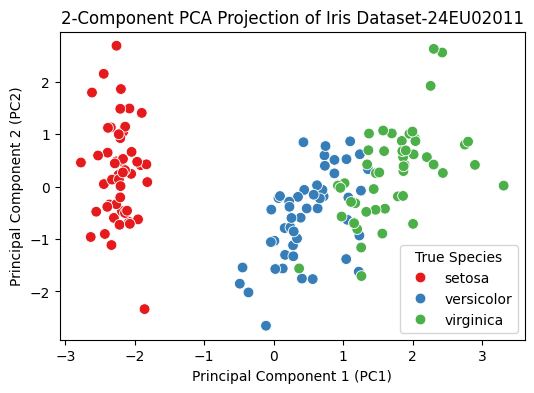

In [34]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=pca_df, x='PC_1', y='PC2', hue='species_name', palette='Set1', s=60)
plt.title("2-Component PCA Projection of Iris Dataset-24EU02011")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.legend(title='True Species')
plt.show()

In [35]:
explained_variance = pca_model.explained_variance_ratio_


In [36]:
explained_variance = pca_model.explained_variance_ratio_

In [37]:
print("Explained Variance per Component:")

Explained Variance per Component:


In [38]:
for i, var in enumerate(explained_variance):
    print(f"  PC{i+1}: {var*100:.2f}%")

  PC1: 72.96%
  PC2: 22.85%


In [39]:
cumulative_variance = np.sum(explained_variance)


In [40]:
print(f"\nTotal Cumulative Variance Retained by 2 Components: {cumulative_variance*100:.2f}%")


Total Cumulative Variance Retained by 2 Components: 95.81%


In [41]:
import numpy as np

In [42]:
import pandas as pd

In [43]:
import matplotlib.pyplot as plt


In [44]:
from sklearn.datasets import load_iris

In [45]:
from sklearn.model_selection import train_test_split


In [46]:
from sklearn.preprocessing import StandardScaler

In [47]:
from sklearn.decomposition import PCA


In [48]:
from sklearn.linear_model import LogisticRegression

In [49]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [50]:
iris = load_iris()


In [51]:
X = iris.data                 # Input features

In [52]:
y = iris.target               # Target labels

In [53]:
feature_names = iris.feature_names

In [54]:
target_names = iris.target_names


In [55]:
print("Dataset Shape:", X.shape)

Dataset Shape: (150, 4)


In [56]:
print("Features:", feature_names)

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [57]:
print("Classes:", target_names)

Classes: ['setosa' 'versicolor' 'virginica']


In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [59]:
scaler = StandardScaler()

In [60]:
X_train_scaled = scaler.fit_transform(X_train)

In [61]:
X_test_scaled = scaler.transform(X_test)

In [62]:
print("CLASSIFICATION WITHOUT PCA")

CLASSIFICATION WITHOUT PCA


In [63]:
model_without_pca = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [64]:
model_without_pca.fit(
    X_train_scaled,
    y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [65]:
y_pred_without_pca = model_without_pca.predict(
    X_test_scaled
)

In [66]:
accuracy_without_pca = accuracy_score(
    y_test,
    y_pred_without_pca
)

In [67]:
print("Accuracy without PCA:",
      accuracy_without_pca)


Accuracy without PCA: 0.9333333333333333


In [68]:
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_without_pca,
        target_names=target_names
    )
)


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [69]:
print("COMPARISON")

COMPARISON


In [70]:
pca = PCA(
    n_components=2
)

In [71]:
X_train_pca = pca.fit_transform(
    X_train_scaled
)

In [72]:
X_test_pca = pca.transform(
    X_test_scaled
)

In [73]:
print("Explained Variance Ratio:",
      pca.explained_variance_ratio_)


Explained Variance Ratio: [0.72677234 0.23066667]


In [74]:
print("Total Explained Variance:",
      pca.explained_variance_ratio_.sum())


Total Explained Variance: 0.9574390106545363


In [75]:
model_with_pca = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [76]:
model_with_pca.fit(
    X_train_pca,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [77]:
y_pred_with_pca = model_with_pca.predict(
    X_test_pca
)

In [78]:
accuracy_with_pca = accuracy_score(
    y_test,
    y_pred_with_pca
)

In [79]:
print("Accuracy with PCA:",
      accuracy_with_pca)


Accuracy with PCA: 0.9


In [80]:
print("\nClassification Report:")


Classification Report:


In [81]:
print(
    classification_report(
        y_test,
        y_pred_with_pca,
        target_names=target_names
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



In [82]:
print("COMPARISON")

COMPARISON


In [83]:
comparison = pd.DataFrame({
    "Method": [
        "Without PCA",
        "With PCA"
    ],
    "Number of Features": [
        X_train_scaled.shape[1],
        X_train_pca.shape[1]
    ],
    "Accuracy": [
        accuracy_without_pca,
        accuracy_with_pca
    ]
})

In [84]:
print(comparison)


        Method  Number of Features  Accuracy
0  Without PCA                   4  0.933333
1     With PCA                   2  0.900000


In [85]:
plt.figure(figsize=(8, 6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

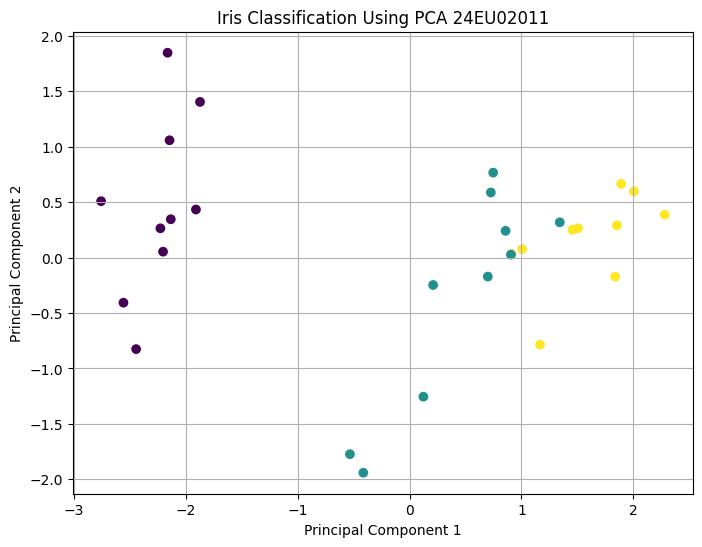

In [86]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c=y_test
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Iris Classification Using PCA 24EU02011")
plt.grid()

plt.show()

In [87]:
import warnings


In [88]:
warnings.filterwarnings("ignore")

In [89]:
from sklearn.cluster import KMeans


In [90]:
import matplotlib.pyplot as plt

In [91]:
wcss = []

In [92]:

k_range = range(1, 11)

In [93]:
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


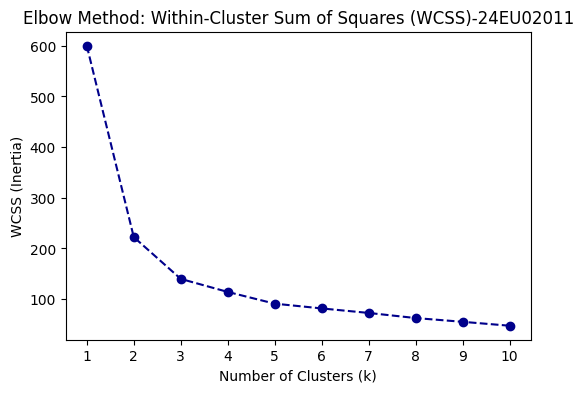

In [94]:
plt.figure(figsize=(6, 4))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='darkblue')
plt.title("Elbow Method: Within-Cluster Sum of Squares (WCSS)-24EU02011")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(k_range)
plt.show()

In [95]:
from sklearn.metrics import silhouette_score


In [96]:
silhouette_scores = []

In [97]:
k_eval = range(2, 6)


In [98]:
for k in k_eval:
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels_temp)
    silhouette_scores.append(score)


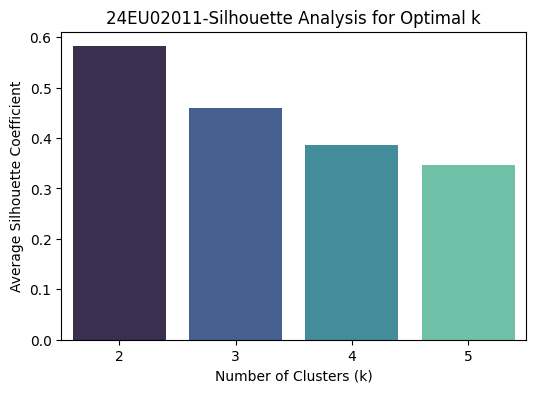

In [99]:
plt.figure(figsize=(6, 4))
sns.barplot(x=list(k_eval), y=silhouette_scores, palette='mako')
plt.title("24EU02011-Silhouette Analysis for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Average Silhouette Coefficient")
plt.show()


In [100]:
best_k = k_eval[np.argmax(silhouette_scores)]

In [101]:
print(f"k = {best_k} yielded the highest silhouette coefficient ({max(silhouette_scores):.4f}).")


k = 2 yielded the highest silhouette coefficient (0.5818).


In [102]:
kmeans_raw = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)

In [103]:
kmeans_raw_labels = kmeans_raw.fit_predict(X_scaled)

In [104]:
iris_df['cluster_raw'] = kmeans_raw_labels

In [105]:
print("K-Means clustering complete. First 5 sample allocations:")

K-Means clustering complete. First 5 sample allocations:


In [106]:
print(iris_df[['species_name', 'cluster_raw']].head(5))


  species_name  cluster_raw
0       setosa            1
1       setosa            1
2       setosa            1
3       setosa            1
4       setosa            1


In [107]:
raw_centroids_scaled = kmeans_raw.cluster_centers_

In [108]:
raw_centroids_physical = scaler.inverse_transform(raw_centroids_scaled)

In [109]:
centroids_df = pd.DataFrame(data=raw_centroids_physical, columns=features)

In [110]:
centroids_df.index = [f"Cluster_{i}" for i in range(3)]

In [111]:
print("--- Estimated Cluster Centroids (Original Physical Units - cm) ---")

--- Estimated Cluster Centroids (Original Physical Units - cm) ---


In [112]:
print(centroids_df)

           sepal length (cm)  sepal width (cm)  petal length (cm)  \
Cluster_0           5.799612          2.653772           4.382414   
Cluster_1           4.992043          3.429444           1.471740   
Cluster_2           6.792945          3.087827           5.524364   

           petal width (cm)  
Cluster_0          1.418814  
Cluster_1          0.251935  
Cluster_2          1.977790  


In [113]:
plt.figure(figsize=(6, 4))


<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

In [114]:
raw_data = scaler.inverse_transform(X_scaled)

<Axes: >

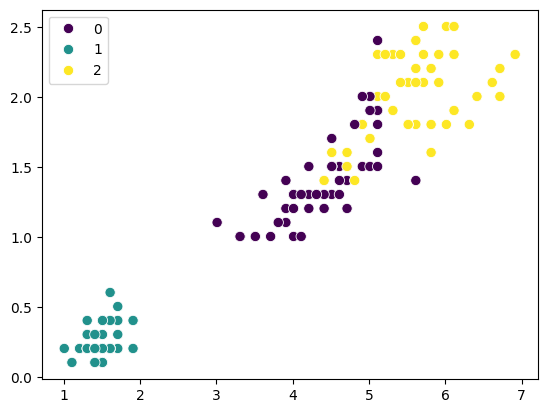

In [115]:
sns.scatterplot(x=raw_data[:, 2], y=raw_data[:, 3], hue=kmeans_raw_labels, palette='viridis', s=55, legend='full')

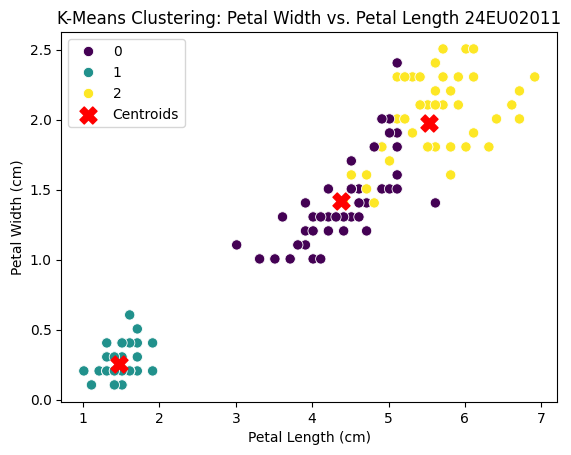

In [116]:
sns.scatterplot(x=raw_data[:, 2], y=raw_data[:, 3], hue=kmeans_raw_labels, palette='viridis', s=55, legend='full')

# Plot the calculated centroids on the same canvas
plt.scatter(
    raw_centroids_physical[:, 2],
    raw_centroids_physical[:, 3],
    color='red',
    marker='X',
    s=150,
    label='Centroids'
)

plt.title("K-Means Clustering: Petal Width vs. Petal Length 24EU02011")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.legend()
plt.show()

In [117]:
import warnings


In [118]:
warnings.filterwarnings("ignore")

In [119]:
from sklearn.cluster import KMeans

In [120]:
kmeans_pca = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)

In [121]:
kmeans_pca_labels = kmeans_pca.fit_predict(X_pca)

In [122]:
iris_df['cluster_pca'] = kmeans_pca_labels

In [123]:
print("PCA space K-Means clustering completed successfully.")

PCA space K-Means clustering completed successfully.


In [124]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

In [125]:
sil_raw = silhouette_score(X_scaled, kmeans_raw_labels)

In [126]:
ch_raw = calinski_harabasz_score(X_scaled, kmeans_raw_labels)


In [127]:
sil_pca = silhouette_score(X_pca, kmeans_pca_labels)

In [128]:
ch_pca = calinski_harabasz_score(X_pca, kmeans_pca_labels)

In [129]:
print("--- Internal Validation (Unsupervised Quality Metrics) ---")

--- Internal Validation (Unsupervised Quality Metrics) ---


In [130]:
print(f"Raw 4D Feature Space  -> Silhouette Score: {sil_raw:.4f} | Calinski-Harabasz: {ch_raw:.2f}")

Raw 4D Feature Space  -> Silhouette Score: 0.4599 | Calinski-Harabasz: 241.90


In [131]:
print(f"PCA 2D Reduced Space -> Silhouette Score: {sil_pca:.4f} | Calinski-Harabasz: {ch_pca:.2f}")


PCA 2D Reduced Space -> Silhouette Score: 0.5092 | Calinski-Harabasz: 293.86


In [132]:
import matplotlib.pyplot as plt

In [133]:
import seaborn as sns

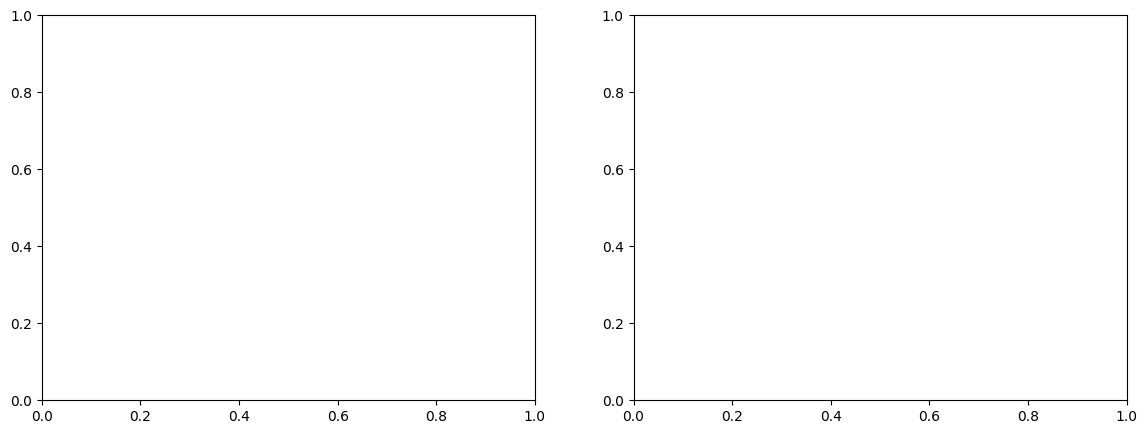

In [134]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

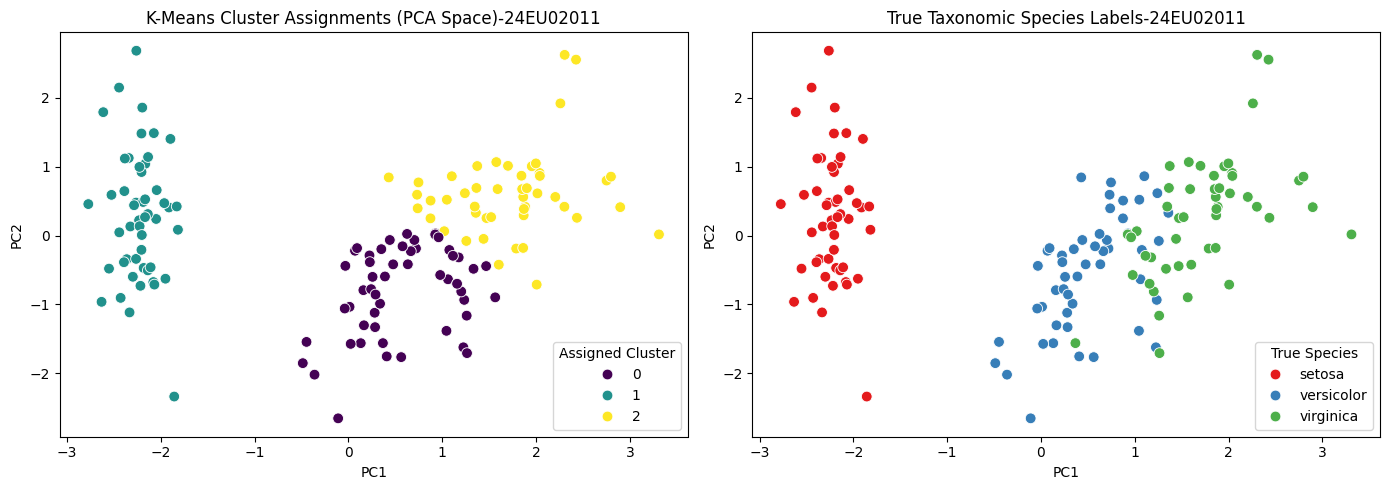

In [135]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: PCA Coordinates colored by K-Means cluster allocations
sns.scatterplot(
    data=pca_df, x='PC_1', y='PC2', hue=kmeans_pca_labels,
    palette='viridis', s=60, ax=axes[0]
)
axes[0].set_title("K-Means Cluster Assignments (PCA Space)-24EU02011")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(title='Assigned Cluster')

# Plot 2: PCA Coordinates colored by true species labels
sns.scatterplot(
    data=pca_df, x='PC_1', y='PC2', hue='species_name',
    palette='Set1', s=60, ax=axes[1]
)
axes[1].set_title("True Taxonomic Species Labels-24EU02011")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend(title='True Species')

plt.tight_layout()
plt.show()

In [136]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari_raw = adjusted_rand_score(y_true, kmeans_raw_labels)
nmi_raw = normalized_mutual_info_score(y_true, kmeans_raw_labels)

ari_pca = adjusted_rand_score(y_true, kmeans_pca_labels)
nmi_pca = normalized_mutual_info_score(y_true, kmeans_pca_labels)

comparison_metrics = pd.DataFrame(
    data=[
        [sil_raw, ch_raw, ari_raw, nmi_raw],
        [sil_pca, ch_pca, ari_pca, nmi_pca]
    ],
    columns=['Silhouette_Score', 'Calinski_Harabasz', 'Adjusted_Rand_Index', 'Normalized_Mutual_Info'],
    index=['Standardized Raw Space (4D)', 'PCA Reduced Space (2D)']
)